# Machine Learning Lab Activity Book — Complete Exercises
**Course:** 23CSE301 Machine Learning  
**Source:** ML Lab Activity Book v1.8  
**Purpose:** Complete Python implementations for all exercises listed in the lab activity book, with dataset-independent/local examples where the book references external datasets.

> The lab book covers Linear Regression, Logistic Regression, Decision Trees, SVM, KNN, K-Means, PCA and Random Forests. The implementations below follow the terminology and workflow shown in the book.

In [18]:
# Common libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_squared_error, r2_score, roc_curve, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Linear Regression — Exercise 1
**Task:** Train a model to predict taxi fare using the Chicago Taxi Trips dataset.

This notebook uses a reproducible synthetic taxi-style dataset when the external Chicago dataset is not locally available. Replace `taxi_df` with the downloaded Chicago Taxi Trips data if required by your faculty.

Coefficients: [2.20378939 0.00292103 0.3501714 ]
Intercept: 3.6287158826939745
MSE: 9.94359144008969
R²: 0.9624379757534289


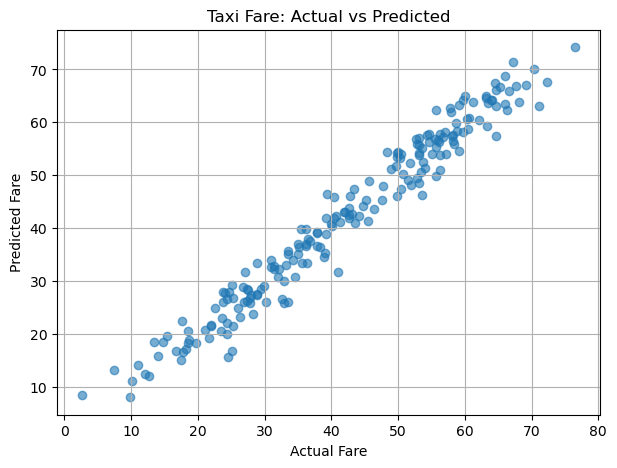

In [19]:
# Taxi fare regression — reproducible lab dataset
rng = np.random.default_rng(RANDOM_STATE)
n = 1000

taxi_df = pd.DataFrame({
    "trip_miles": rng.uniform(0.5, 25, n),
    "trip_seconds": rng.uniform(180, 3600, n),
    "tips": rng.uniform(0, 20, n),
})
taxi_df["fare"] = (
    3.5
    + 2.2 * taxi_df["trip_miles"]
    + 0.003 * taxi_df["trip_seconds"]
    + 0.35 * taxi_df["tips"]
    + rng.normal(0, 3, n)
)

X = taxi_df[["trip_miles", "trip_seconds", "tips"]]
y = taxi_df["fare"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

taxi_model = LinearRegression()
taxi_model.fit(X_train, y_train)
taxi_pred = taxi_model.predict(X_test)

print("Coefficients:", taxi_model.coef_)
print("Intercept:", taxi_model.intercept_)
print("MSE:", mean_squared_error(y_test, taxi_pred))
print("R²:", r2_score(y_test, taxi_pred))

plt.figure(figsize=(7,5))
plt.scatter(y_test, taxi_pred, alpha=0.6)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Taxi Fare: Actual vs Predicted")
plt.grid(True)
plt.show()

## 2. Linear Regression — Exercise 2
**Task:** Predict body weight using height and gender as independent variables.

Gender is encoded numerically for the regression model.

In [20]:
# Body-weight dataset based on the exercise structure in the lab book
weight_df = pd.DataFrame({
    "weight": [79, 89, 73, 95, 82, 85, 70, 71, 64, 69, 77, 84],
    "height": [1.80, 1.80, 1.82, 1.70, 1.87, 1.65, 1.80, 1.74, 1.67, 1.64, 1.75, 1.78],
    "age":    [35, 35, 29, 30, 33, 31, 42, 22, 52, 44, 28, 36],
    "gender": ["Male","Male","Male","Male","Male","Female","Female","Female","Female","Female","Male","Male"]
})

weight_df["gender_encoded"] = weight_df["gender"].map({"Female": 0, "Male": 1})

X = weight_df[["height", "gender_encoded"]]
y = weight_df["weight"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

weight_model = LinearRegression()
weight_model.fit(X_train, y_train)
weight_pred = weight_model.predict(X_test)

print("Predictions:", np.round(weight_pred, 2))
print("MSE:", mean_squared_error(y_test, weight_pred))
print("R²:", r2_score(y_test, weight_pred))

Predictions: [87.75 77.87 84.17]
MSE: 73.6904543605301
R²: -2.947702912171255


## 3. Logistic Regression — Exercise 1
**Task:** Predict graduate-school admission using GRE, GPA and prestige-style features.

A synthetic dataset is generated to keep this notebook self-contained.

Confusion Matrix:
 [[  8  37]
 [  9 106]]
Accuracy: 0.7125
              precision    recall  f1-score   support

           0       0.47      0.18      0.26        45
           1       0.74      0.92      0.82       115

    accuracy                           0.71       160
   macro avg       0.61      0.55      0.54       160
weighted avg       0.67      0.71      0.66       160

ROC-AUC: 0.7201932367149759


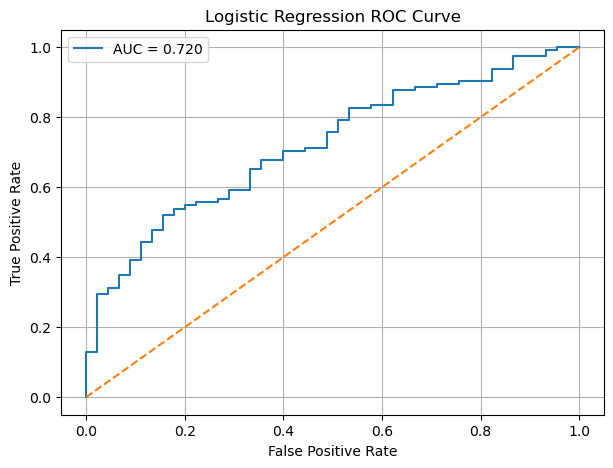

In [21]:
rng = np.random.default_rng(RANDOM_STATE)
n = 800

admission = pd.DataFrame({
    "gre": rng.normal(310, 15, n).clip(260, 340),
    "gpa": rng.normal(3.4, 0.35, n).clip(2.0, 4.0),
    "prestige": rng.integers(1, 5, n)
})

logit = (
    -10
    + 0.025 * admission["gre"]
    + 1.4 * admission["gpa"]
    - 0.55 * admission["prestige"]
)
prob = 1 / (1 + np.exp(-logit))
admission["admit"] = rng.binomial(1, prob)

X = admission[["gre", "gpa", "prestige"]]
y = admission["admit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_model.fit(X_train_s, y_train)
y_pred = log_model.predict(X_test_s)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

y_prob = log_model.predict_proba(X_test_s)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## 4. Logistic Regression — Exercise 2
**Task:** For the given dataset, determine whether logistic regression is suitable for a particular classification problem.

Here, the breast-cancer dataset is used as a binary classification example.

In [22]:
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer(as_frame=True)
bc_df = bc.frame.copy()

X = bc_df.drop(columns=["target"])
y = bc_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
model.fit(X_train_s, y_train)
pred = model.predict(X_test_s)

print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Confusion Matrix:
 [[41  1]
 [ 1 71]]
Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 5. Logistic Regression — Exercise 3
**Task:** Predict which product a particular customer is most likely to buy.

The example creates a multiclass customer-product dataset and uses multinomial logistic regression.

In [23]:
# Customer product prediction — robust multiclass dataset
rng = np.random.default_rng(RANDOM_STATE)
n = 900

customers = pd.DataFrame({
    "age": rng.integers(18, 70, n),
    "income": rng.integers(20000, 150000, n),
    "website_visits": rng.integers(1, 30, n),
    "previous_purchases": rng.integers(0, 15, n)
})

# Standardize the features before constructing class scores.
# This keeps the features on comparable scales and ensures all 3
# product classes can occur in the synthetic dataset.
z = (customers - customers.mean()) / customers.std()

score_a = (
    0.8 * z["income"]
    + 0.8 * z["website_visits"]
    - 0.3 * z["age"]
)

score_b = (
    0.3 * z["income"]
    + 1.0 * z["previous_purchases"]
    - 0.2 * z["age"]
)

score_c = (
    -0.4 * z["income"]
    + 0.3 * z["website_visits"]
    + 0.9 * z["age"]
)

scores = np.vstack([score_a, score_b, score_c]).T
customers["product"] = np.argmax(scores, axis=1)

# Verify that this is actually a multiclass problem
print("Product class distribution:")
print(customers["product"].value_counts().sort_index())

assert customers["product"].nunique() >= 2, "Dataset must contain at least two product classes."

X = customers.drop(columns=["product"])
y = customers["product"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

model = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    random_state=RANDOM_STATE
)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nAccuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))

new_customer = pd.DataFrame({
    "age": [24],
    "income": [70000],
    "website_visits": [12],
    "previous_purchases": [4]
})

predicted_product = model.predict(new_customer)[0]
print("Predicted product for new customer:", predicted_product)

Product class distribution:
product
0    282
1    286
2    332
Name: count, dtype: int64

Confusion Matrix:
 [[56  0  0]
 [ 0 57  0]
 [ 1  0 66]]

Accuracy: 0.9944444444444445

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        56
           1       1.00      1.00      1.00        57
           2       1.00      0.99      0.99        67

    accuracy                           0.99       180
   macro avg       0.99      1.00      0.99       180
weighted avg       0.99      0.99      0.99       180

Predicted product for new customer: 0


## 6. Decision Tree Classifier — Exercise
**Task:** Use the diabetes dataset and predict the class label using a Decision Tree.

   pregnant  glucose  bp  skin  insulin   bmi  pedigree  age  label
0         6      148  72    35        0  33.6     0.627   50      1
1         1       85  66    29        0  26.6     0.351   31      0
2         8      183  64     0        0  23.3     0.672   32      1
3         1       89  66    23       94  28.1     0.167   21      0
4         0      137  40    35      168  43.1     2.288   33      1

Missing values:
 pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64
Confusion Matrix:
 [[78 22]
 [24 30]]
Accuracy: 0.7012987012987013
              precision    recall  f1-score   support

           0       0.76      0.78      0.77       100
           1       0.58      0.56      0.57        54

    accuracy                           0.70       154
   macro avg       0.67      0.67      0.67       154
weighted avg       0.70      0.70      0.70       154



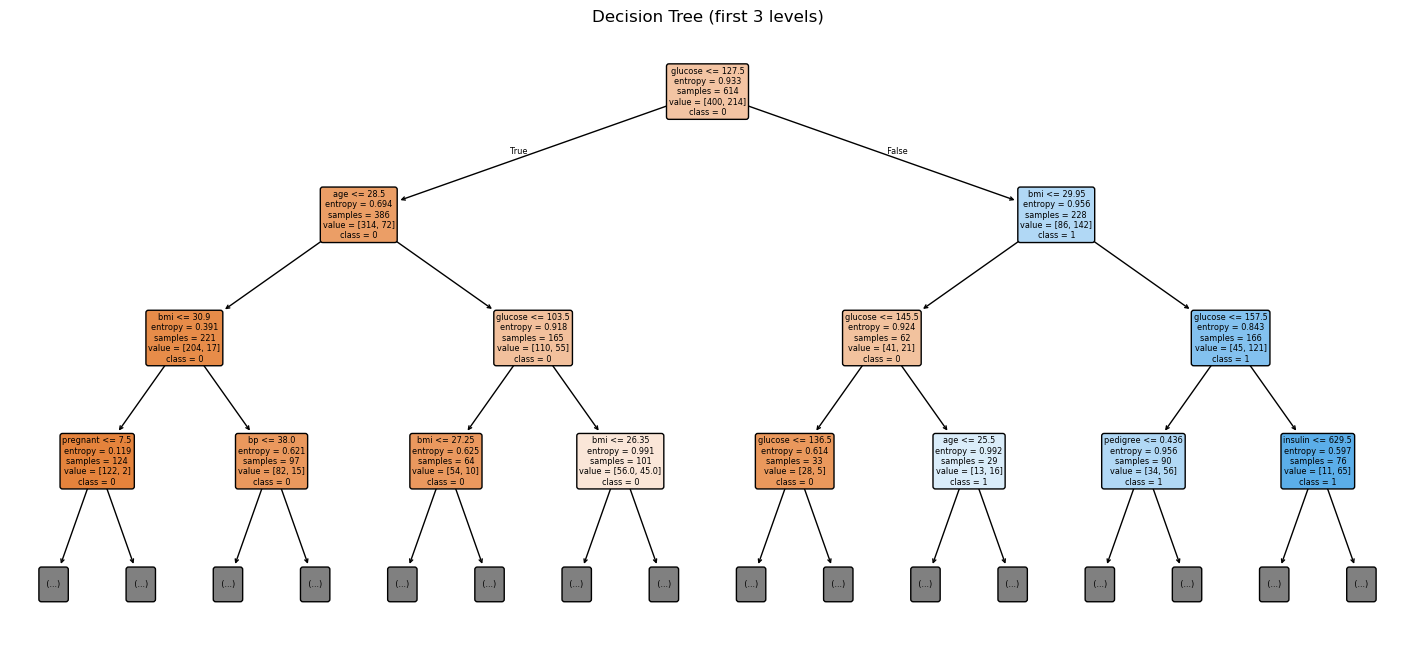

In [24]:
# Diabetes dataset
diabetes = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv",
    header=None
)
diabetes.columns = [
    "pregnant","glucose","bp","skin","insulin","bmi","pedigree","age","label"
]

print(diabetes.head())
print("\nMissing values:\n", diabetes.isnull().sum())

feature_cols = ["pregnant","insulin","bmi","age","glucose","bp","pedigree"]
X = diabetes[feature_cols]
y = diabetes["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5, stratify=y
)

dt = DecisionTreeClassifier(criterion="entropy", random_state=5)
dt.fit(X_train, y_train)
pred = dt.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

plt.figure(figsize=(18,8))
plot_tree(dt, feature_names=feature_cols, class_names=["0","1"],
          filled=True, max_depth=3, rounded=True)
plt.title("Decision Tree (first 3 levels)")
plt.show()

## 7. Support Vector Machine — Exercise 1
**Task:** Generate a random dataset and classify it using SVM.

In [25]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=500, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1,
    class_sep=1.2, random_state=RANDOM_STATE
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

for kernel in ["rbf", "linear"]:
    svm = SVC(kernel=kernel, random_state=RANDOM_STATE)
    svm.fit(X_train_s, y_train)
    pred = svm.predict(X_test_s)
    print(f"{kernel.upper()} kernel")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
    print()

RBF kernel
Accuracy: 0.9333333333333333
Confusion Matrix:
 [[65 10]
 [ 0 75]]

LINEAR kernel
Accuracy: 0.9333333333333333
Confusion Matrix:
 [[65 10]
 [ 0 75]]



## 8. Support Vector Machine — Exercise 2
**Task:** Classify email as spam or non-spam using text-like features.

The example uses numeric features representing message characteristics such as word frequency and message length.

In [26]:
rng = np.random.default_rng(RANDOM_STATE)
n = 700

spam_df = pd.DataFrame({
    "keyword_frequency": rng.poisson(5, n),
    "message_length": rng.integers(20, 500, n),
    "link_count": rng.poisson(2, n),
    "capital_ratio": rng.uniform(0, 0.8, n)
})
spam_score = (
    spam_df["keyword_frequency"]
    + 1.5*spam_df["link_count"]
    + 3*spam_df["capital_ratio"]
    + rng.normal(0, 2, n)
)
spam_df["spam"] = (spam_score > spam_score.median()).astype(int)

X = spam_df.drop(columns=["spam"])
y = spam_df["spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

svm = SVC(kernel="rbf", random_state=RANDOM_STATE)
svm.fit(X_train_s, y_train)
pred = svm.predict(X_test_s)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.86      0.79      0.83       105
           1       0.81      0.88      0.84       105

    accuracy                           0.83       210
   macro avg       0.84      0.83      0.83       210
weighted avg       0.84      0.83      0.83       210



## 9. KNN — Exercise 1
**Task:** Identify a new letter/number using a KNN classifier based on handwriting-style features.

The digits dataset from scikit-learn is used as a self-contained image-feature example.

In [27]:
from sklearn.datasets import load_digits

digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2)
knn.fit(X_train_s, y_train)
pred = knn.predict(X_test_s)

print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.9638888888888889
Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 36  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  1 36  0  0  0  0  0  0]
 [ 0  0  0  0 34  0  0  2  0  0]
 [ 0  0  0  0  0 36  0  0  0  1]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  1  0 35  0  0]
 [ 0  3  1  0  0  0  0  0 31  0]
 [ 0  0  0  0  1  0  1  1  1 32]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       0.95      1.00      0.97        35
           3       1.00      0.97      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      0.97      0.97        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       0.97      0.89      0.93        35
           9       0.97      0.89      0.93        36

    accuracy             

## 10. KNN — Exercise 2
**Task:** Calculate the distance between a new entry and existing values using Euclidean distance.

In [28]:
# Given table from the lab exercise
knn_table = pd.DataFrame({
    "Brightness": [40, 50, 60, 10, 70, 60, 25],
    "Saturation": [20, 50, 90, 25, 70, 10, 80],
    "Class": ["Red", "Blue", "Blue", "Red", "Blue", "Red", "Blue"]
})

new_point = np.array([45, 40])

knn_table["Euclidean_Distance"] = np.sqrt(
    (knn_table["Brightness"] - new_point[0])**2 +
    (knn_table["Saturation"] - new_point[1])**2
)

print(knn_table.sort_values("Euclidean_Distance"))

k = 3
nearest = knn_table.nsmallest(k, "Euclidean_Distance")
print("\nNearest classes:", nearest["Class"].tolist())
print("Predicted class:", nearest["Class"].mode()[0])

   Brightness  Saturation Class  Euclidean_Distance
1          50          50  Blue           11.180340
0          40          20   Red           20.615528
5          60          10   Red           33.541020
3          10          25   Red           38.078866
4          70          70  Blue           39.051248
6          25          80  Blue           44.721360
2          60          90  Blue           52.201533

Nearest classes: ['Blue', 'Red', 'Red']
Predicted class: Red


## 11. K-Means Clustering — Exercise 1
**Task:** Implement K-Means clustering for Geyser's Eruptions dataset and segregate waiting time into clusters.

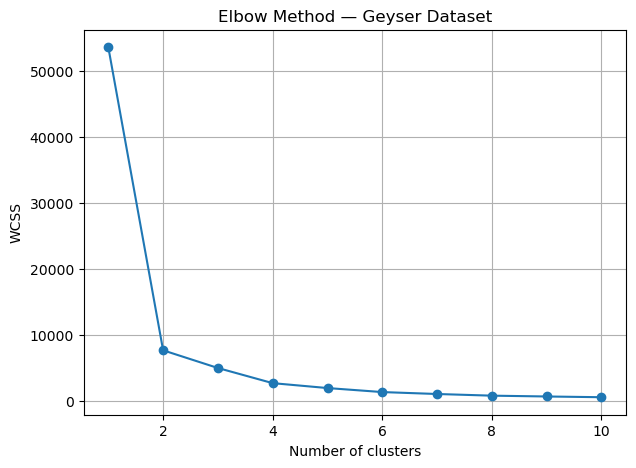

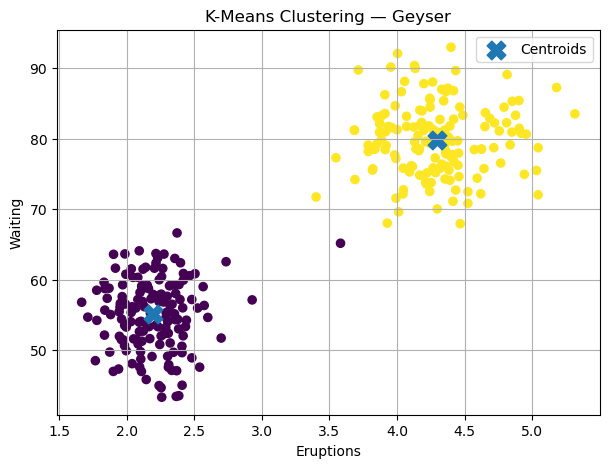

Cluster centers:
 [[ 2.19659164 55.19688691]
 [ 4.29369274 79.85498201]]


In [29]:
# Self-contained Old Faithful/Geyser-style dataset
rng = np.random.default_rng(RANDOM_STATE)

geyser = pd.DataFrame({
    "eruptions": np.r_[rng.normal(2.2, 0.25, 150), rng.normal(4.3, 0.35, 150)],
    "waiting": np.r_[rng.normal(55, 5, 150), rng.normal(80, 5, 150)]
})

X = geyser[["eruptions", "waiting"]]

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init="k-means++", random_state=RANDOM_STATE, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method — Geyser Dataset")
plt.grid(True)
plt.show()

km = KMeans(n_clusters=2, init="k-means++", random_state=RANDOM_STATE, n_init=10)
geyser["cluster"] = km.fit_predict(X)

plt.figure(figsize=(7,5))
plt.scatter(geyser["eruptions"], geyser["waiting"], c=geyser["cluster"], s=35)
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
            s=180, marker="X", label="Centroids")
plt.xlabel("Eruptions")
plt.ylabel("Waiting")
plt.title("K-Means Clustering — Geyser")
plt.legend()
plt.grid(True)
plt.show()

print("Cluster centers:\n", km.cluster_centers_)

## 12. K-Means Clustering — Exercise 2
**Task:** Compress an image using K-Means clustering.

Each pixel is represented by its RGB values and clustered into a smaller number of colors.

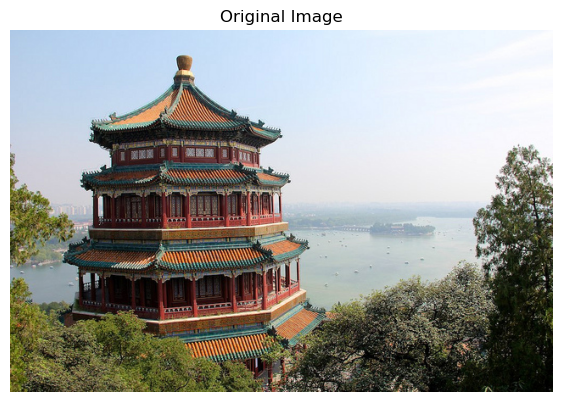

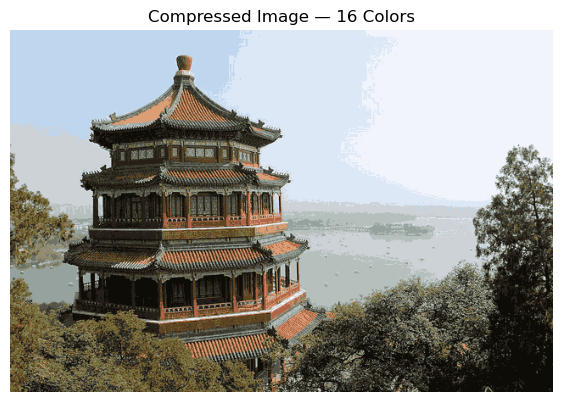

Original colors: 96615
Compressed colors: 16


In [30]:
from sklearn.datasets import load_sample_image

# Use a built-in sample image
image = load_sample_image("china.jpg")
plt.figure(figsize=(7,5))
plt.imshow(image)
plt.axis("off")
plt.title("Original Image")
plt.show()

pixels = image.reshape(-1, 3).astype(float)

n_colors = 16
km_img = KMeans(n_clusters=n_colors, random_state=RANDOM_STATE, n_init=5)
labels = km_img.fit_predict(pixels)

compressed = km_img.cluster_centers_[labels].reshape(image.shape).astype(np.uint8)

plt.figure(figsize=(7,5))
plt.imshow(compressed)
plt.axis("off")
plt.title(f"Compressed Image — {n_colors} Colors")
plt.show()

print("Original colors:", len(np.unique(pixels, axis=0)))
print("Compressed colors:", n_colors)

## 13. PCA — Exercise 1
**Task:** Identify the principal component for a dataset.

The breast-cancer dataset is standardized and reduced to principal components.

In [31]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca_full.explained_variance_ratio_)

print("\nFirst principal component loadings:")
loadings = pd.Series(
    pca_full.components_[0],
    index=data.feature_names
).sort_values(key=np.abs, ascending=False)
print(loadings.head(10))

Explained variance ratio:
[4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]

First principal component loadings:
mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
mean compactness        0.239285
worst perimeter         0.236640
worst concavity         0.228768
worst radius            0.227997
mean perimeter          0.227537
worst area              0.224871
mean area               0.220995
dtype: float64


## 14. PCA — Exercise 2
**Task:** Apply PCA and visualize the first two principal components.

Shape after PCA: (569, 2)
Explained variance ratio: [0.44272026 0.18971182]
Total explained variance: 0.6324320765155946


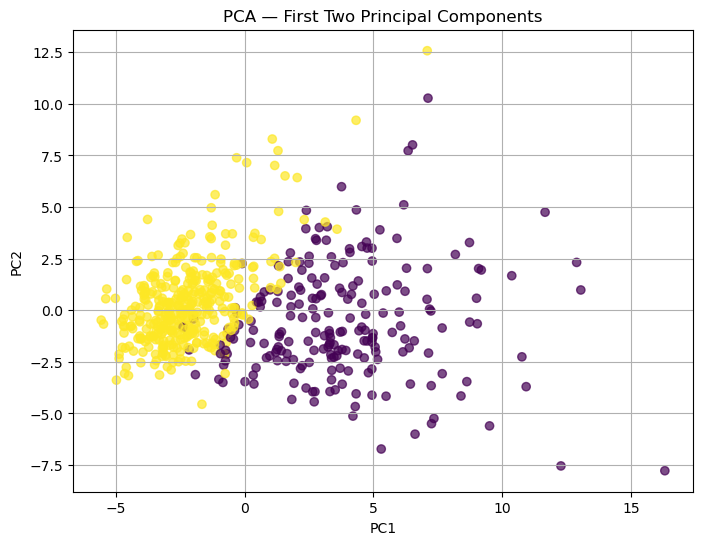

In [32]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA — First Two Principal Components")
plt.grid(True)
plt.show()

## 15. Random Forest — Exercise 1
**Task:** Build a Random Forest classifier and evaluate it using a confusion matrix and classification report.

Confusion Matrix:
 [[ 60   4]
 [  5 102]]
Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        64
           1       0.96      0.95      0.96       107

    accuracy                           0.95       171
   macro avg       0.94      0.95      0.94       171
weighted avg       0.95      0.95      0.95       171



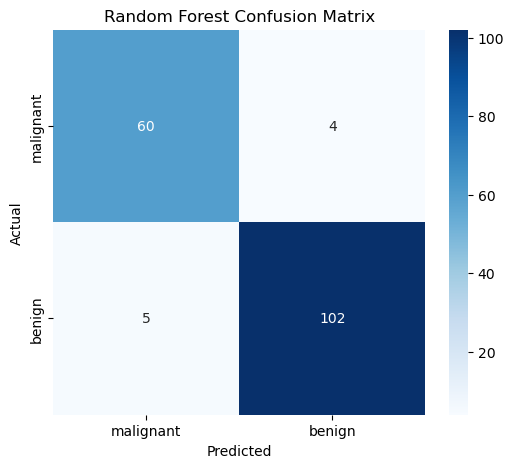

In [33]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    random_state=0
)
rf.fit(X_train_s, y_train)
pred = rf.predict(X_test_s)

print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

## 16. Random Forest — Exercise 2
**Task:** Consider the fruit-basket ensemble shown in the lab book. Each decision tree produces a class, and majority voting determines the final class.

The following code demonstrates the majority-voting principle directly.

In [34]:
# Majority voting demonstration
tree_predictions = np.array([
    "Class-A",
    "Class-A",
    "Class-B",
    "Class-A",
    "Class-B",
    "Class-A",
    "Class-A"
])

final_class = pd.Series(tree_predictions).mode()[0]

print("Individual tree predictions:", tree_predictions)
print("Vote counts:")
print(pd.Series(tree_predictions).value_counts())
print("Final class by majority voting:", final_class)

Individual tree predictions: ['Class-A' 'Class-A' 'Class-B' 'Class-A' 'Class-B' 'Class-A' 'Class-A']
Vote counts:
Class-A    5
Class-B    2
Name: count, dtype: int64
Final class by majority voting: Class-A
